# Modelos de Riesgo con Machine Learning Tradicional y MLflow

## 🎯 Objetivo del Laboratorio

Este notebook está diseñado para el equipo de la autoridad fiscal federal de México y cubre el ciclo de vida completo de desarrollo, registro y despliegue de modelos de riesgo utilizando técnicas de Machine Learning tradicional y MLflow en Databricks.

## 📋 Contenido

1. **Configuración del Entorno** - Instalación de librerías necesarias
2. **Generación de Datos Sintéticos** - Creación de dataset de riesgo fiscal
3. **Análisis Exploratorio de Datos (EDA)** - Comprensión profunda del dataset
4. **Preprocesamiento de Datos** - Preparación de datos para modelado
5. **Entrenamiento de Modelos con MLflow** - Desarrollo y seguimiento de experimentos
6. **Evaluación de Modelos** - Métricas y visualizaciones de rendimiento
7. **Registro y Versionado de Modelos** - MLflow Model Registry
8. **Despliegue y CI/CD** - Mejores prácticas para producción

## 🔍 ¿Qué es MLflow?

MLflow es una plataforma open-source para gestionar el ciclo de vida completo de Machine Learning, incluyendo:

* **MLflow Tracking**: Registro de experimentos, parámetros, métricas y artefactos
* **MLflow Projects**: Empaquetado de código ML en formato reutilizable
* **MLflow Models**: Gestión y despliegue de modelos en diversos entornos
* **MLflow Model Registry**: Almacén centralizado de modelos con versionado y gestión de ciclo de vida

## 🚀 MLOps y DevOps para Modelos de ML

MLOps combina Machine Learning, DevOps y Data Engineering para:

* **Reproducibilidad**: Capacidad de recrear exactamente los mismos resultados
* **Trazabilidad**: Seguimiento completo de experimentos y versiones de modelos
* **Automatización**: CI/CD para entrenamiento, validación y despliegue
* **Monitoreo**: Supervisión del rendimiento de modelos en producción
* **Gobernanza**: Control de acceso, auditoría y cumplimiento normativo

---

**Nota**: Este notebook utiliza datos sintéticos para fines educativos. En producción, se utilizarían datos reales de contribuyentes con las medidas de seguridad y privacidad apropiadas.

In [0]:
# Instalación de librerías necesarias con versiones fijas para reproducibilidad
%pip install mlflow scikit-learn==1.4.0 pandas==2.1.4 numpy==1.26.3 matplotlib==3.8.2 seaborn==0.13.1 ydata-profiling==4.8.3 optuna==3.5.0 category-encoders==2.6.3 xgboost==2.0.3 --quiet

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Reiniciar el kernel de Python para cargar las librerías instaladas
dbutils.library.restartPython()

In [0]:
import mlflow
EXPERIMENT_NAME = "/Users/{}/riesgo_ml_tradicional".format(
    spark.sql("SELECT current_user()").collect()[0][0]
)
print(EXPERIMENT_NAME)

mlflow.set_experiment(EXPERIMENT_NAME)

/Users/dan.pechi@databricks.com/riesgo_ml_tradicional


<Experiment: artifact_location='dbfs:/databricks/mlflow-tracking/2106771804875176', creation_time=1769575081391, experiment_id='2106771804875176', last_update_time=1769575081391, lifecycle_stage='active', name='/Users/dan.pechi@databricks.com/riesgo_ml_tradicional', tags={'mlflow.experiment.sourceName': '/Users/dan.pechi@databricks.com/riesgo_ml_tradicional',
 'mlflow.experimentType': 'MLFLOW_EXPERIMENT',
 'mlflow.ownerEmail': 'dan.pechi@databricks.com',
 'mlflow.ownerId': '8736124592716373'}>

In [0]:
# Librerías para manipulación de datos
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de Machine Learning
import sklearn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
import xgboost as xgb
from category_encoders import OneHotEncoder
import optuna

# MLflow para tracking y registro de modelos
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from mlflow.models import infer_signature

# Configuración
np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Librerías importadas exitosamente")
print(f"MLflow version: {mlflow.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

✅ Librerías importadas exitosamente
MLflow version: 3.8.1
Scikit-learn version: 1.4.0


## 🛠️ Configuración de MLflow

En Databricks, MLflow está preconfigurado y listo para usar. Los experimentos se crean automáticamente y se asocian con este notebook.

**Conceptos clave:**

* **Experiment**: Contenedor para organizar runs relacionados
* **Run**: Ejecución individual de entrenamiento con parámetros, métricas y artefactos
* **Parameters**: Valores de configuración del modelo (ej: learning_rate, max_depth)
* **Metrics**: Métricas de rendimiento (ej: accuracy, F1-score)
* **Artifacts**: Archivos generados (modelos, gráficos, datasets)
* **Tags**: Metadatos para organizar y filtrar runs

### Usando nuestro dataset en Unity Catalog

In [0]:
# Cargar datos desde Unity Catalog y convertir a pandas
print("📥 Cargando datos desde Unity Catalog...\n")

df = spark.table("main.default.riesgo_fiscal_dataset").toPandas()

print(f"✅ Dataset cargado: {df.shape}")
print(f"\n📊 Columnas disponibles:")
print(df.columns.tolist())
print(f"\n🎯 Primeras filas:")
display(df.head())

📥 Cargando datos desde Unity Catalog...

✅ Dataset cargado: (5000, 15)

📊 Columnas disponibles:
['contribuyente_id', 'ingresos_anuales', 'deducciones', 'anos_operando', 'auditorias_previas', 'irregularidades_previas', 'pagos_tardios', 'variacion_ingresos_pct', 'num_empleados', 'sector', 'tamano_empresa', 'region', 'ratio_deducciones', 'nivel_riesgo', 'nivel_riesgo_encoded']

🎯 Primeras filas:


contribuyente_id,ingresos_anuales,deducciones,anos_operando,auditorias_previas,irregularidades_previas,pagos_tardios,variacion_ingresos_pct,num_empleados,sector,tamano_empresa,region,ratio_deducciones,nivel_riesgo,nivel_riesgo_encoded
RFC003001,25293.144337271846,56418.62002592411,23,1,0,2,-12.06989021253117,3.0,Construcción,Pequeña,Sur,223.05894148077874,Medio,1
RFC003002,121713.16924334421,24183.588751302934,24,0,0,0,32.96508943502228,10.0,Tecnología,Pequeña,Norte,19.86932794671715,Bajo,0
RFC003003,237896.670274148,43902.435530692404,13,1,0,3,null,3.0,Construcción,Mediana,Occidente,18.454413624242825,Bajo,0
RFC003004,7508388.994464367,216753.73135932346,21,0,0,2,21.17203886302141,2.0,Comercio,Pequeña,Occidente,2.8868207483539714,Medio,1
RFC003005,1019506.9507748622,597280.4090811025,12,0,0,1,51.47139995510108,5.0,Servicios,Grande,Occidente,58.58522186897772,Medio,1


In [0]:
# Preparar datos para modelado
print("🔧 Preparando datos para modelado...\n")

# Eliminar columnas que no se usarán para el modelo
columns_to_drop = ['contribuyente_id', 'nivel_riesgo_encoded']  # ID y encoding temporal

# Separar features (X) y target (y)
X = df.drop(columns=columns_to_drop + ['nivel_riesgo'])
y = df['nivel_riesgo']

print(f"✅ Features (X): {X.shape}")
print(f"   Columnas: {list(X.columns)}")
print(f"\n✅ Target (y): {y.shape}")
print(f"   Clases: {y.unique()}")
print(f"\n📊 Distribución del target:")
print(y.value_counts())

🔧 Preparando datos para modelado...

✅ Features (X): (5000, 12)
   Columnas: ['ingresos_anuales', 'deducciones', 'anos_operando', 'auditorias_previas', 'irregularidades_previas', 'pagos_tardios', 'variacion_ingresos_pct', 'num_empleados', 'sector', 'tamano_empresa', 'region', 'ratio_deducciones']

✅ Target (y): (5000,)
   Clases: ['Medio' 'Bajo' 'Alto']

📊 Distribución del target:
nivel_riesgo
Bajo     2851
Medio    1856
Alto      293
Name: count, dtype: int64


In [0]:
# Identificar columnas numéricas y categóricas
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"🔢 Columnas numéricas ({len(numeric_features)}):")
print(f"   {numeric_features}")
print(f"\n🏷️  Columnas categóricas ({len(categorical_features)}):")
print(f"   {categorical_features}")

🔢 Columnas numéricas (9):
   ['ingresos_anuales', 'deducciones', 'anos_operando', 'auditorias_previas', 'irregularidades_previas', 'pagos_tardios', 'variacion_ingresos_pct', 'num_empleados', 'ratio_deducciones']

🏷️  Columnas categóricas (3):
   ['sector', 'tamano_empresa', 'region']


In [0]:
# Crear transformadores para columnas numéricas y categóricas
from sklearn.preprocessing import StandardScaler
from category_encoders import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Pipeline para columnas numéricas: imputar valores faltantes y escalar
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para columnas categóricas: imputar valores faltantes y one-hot encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', use_cat_names=True))
])

# Combinar transformadores
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("✅ Pipeline de preprocesamiento creado")

✅ Pipeline de preprocesamiento creado


In [0]:
# Dividir datos en train, validation y test
print("🔀 Dividiendo datos...\n")

# Primero separar test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Luego dividir train y validation (80% train, 20% val del restante)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp  # 0.25 * 0.8 = 0.2
)

print(f"✅ Train set: {X_train.shape}")
print(f"✅ Validation set: {X_val.shape}")
print(f"✅ Test set: {X_test.shape}")
print(f"\n📊 Distribución del target en cada conjunto:")
print(f"\nTrain:\n{y_train.value_counts()}")
print(f"\nValidation:\n{y_val.value_counts()}")
print(f"\nTest:\n{y_test.value_counts()}")

🔀 Dividiendo datos...

✅ Train set: (3000, 12)
✅ Validation set: (1000, 12)
✅ Test set: (1000, 12)

📊 Distribución del target en cada conjunto:

Train:
nivel_riesgo
Bajo     1711
Medio    1114
Alto      175
Name: count, dtype: int64

Validation:
nivel_riesgo
Bajo     570
Medio    371
Alto      59
Name: count, dtype: int64

Test:
nivel_riesgo
Bajo     570
Medio    371
Alto      59
Name: count, dtype: int64


In [0]:
# Ajustar el preprocessor con datos de entrenamiento y transformar todos los conjuntos
print("🔧 Aplicando preprocesamiento...\n")

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(f"✅ Train procesado: {X_train_processed.shape}")
print(f"✅ Validation procesado: {X_val_processed.shape}")
print(f"✅ Test procesado: {X_test_processed.shape}")

# Codificar el target (nivel_riesgo) a valores numéricos
print(f"\n🏷️  Codificando target...")
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print(f"\n✅ Mapeo de clases:")
for idx, class_name in enumerate(label_encoder.classes_):
    print(f"   {class_name} -> {idx}")

print(f"\n✅ Datos listos para entrenamiento de modelos!")

🔧 Aplicando preprocesamiento...

✅ Train procesado: (3000, 23)
✅ Validation procesado: (1000, 23)
✅ Test procesado: (1000, 23)

🏷️  Codificando target...

✅ Mapeo de clases:
   Alto -> 0
   Bajo -> 1
   Medio -> 2

✅ Datos listos para entrenamiento de modelos!


## 🤖 Entrenamiento de Modelos con MLflow Tracking

En esta sección entrenaremos múltiples modelos de clasificación y usaremos MLflow para:

* **Tracking de experimentos**: Registrar parámetros, métricas y artefactos
* **Comparación de modelos**: Evaluar diferentes algoritmos
* **Reproduciblidad**: Garantizar que los experimentos puedan recrearse
* **Versionado**: Mantener historial completo de experimentos

**Modelos a entrenar:**

1. 📊 **Regresión Logística** - Modelo lineal baseline
2. 🌳 **Random Forest** - Ensemble de árboles de decisión
3. 🚀 **XGBoost** - Gradient boosting optimizado

**MLflow Autologging:**

MLflow puede registrar automáticamente parámetros, métricas y modelos para frameworks populares como scikit-learn y XGBoost.

In [0]:
# Entrenar Regresión Logística con MLflow tracking
print("=" * 70)
print("📊 MODELO 1: REGRESIÓN LOGÍSTICA (BASELINE)")
print("=" * 70)

# Habilitar autologging de sklearn
mlflow.sklearn.autolog(log_input_examples=True, log_model_signatures=True)

with mlflow.start_run(run_name="Logistic_Regression_Baseline") as run:
    # Registrar tags personalizados
    mlflow.set_tag("model_type", "Logistic Regression")
    mlflow.set_tag("dataset", "Riesgo Fiscal Sintético")
    mlflow.set_tag("purpose", "Baseline Model")
    
    # Crear y entrenar el modelo
    print("\n🔄 Entrenando modelo...")
    lr_model = LogisticRegression(
        max_iter=1000,
        random_state=42,
        multi_class='multinomial',
        solver='lbfgs'
    )
    
    lr_model.fit(X_train_processed, y_train_encoded)
    
    # Predicciones
    y_train_pred = lr_model.predict(X_train_processed)
    y_val_pred = lr_model.predict(X_val_processed)
    
    # Calcular métricas
    train_accuracy = accuracy_score(y_train_encoded, y_train_pred)
    val_accuracy = accuracy_score(y_val_encoded, y_val_pred)
    val_f1 = f1_score(y_val_encoded, y_val_pred, average='weighted')
    val_precision = precision_score(y_val_encoded, y_val_pred, average='weighted')
    val_recall = recall_score(y_val_encoded, y_val_pred, average='weighted')
    
    # Registrar métricas adicionales manualmente
    mlflow.log_metric("train_accuracy", train_accuracy)
    mlflow.log_metric("val_accuracy", val_accuracy)
    mlflow.log_metric("val_f1_score", val_f1)
    mlflow.log_metric("val_precision", val_precision)
    mlflow.log_metric("val_recall", val_recall)
    
    # Guardar el run_id para referencia
    lr_run_id = run.info.run_id
    
    print(f"\n✅ Modelo entrenado exitosamente")
    print(f"\n📊 Métricas:")
    print(f"   Train Accuracy: {train_accuracy:.4f}")
    print(f"   Val Accuracy:   {val_accuracy:.4f}")
    print(f"   Val F1-Score:   {val_f1:.4f}")
    print(f"   Val Precision:  {val_precision:.4f}")
    print(f"   Val Recall:     {val_recall:.4f}")
    print(f"\n🎯 MLflow Run ID: {lr_run_id}")

print("\n" + "=" * 70)

📊 MODELO 1: REGRESIÓN LOGÍSTICA (BASELINE)

🔄 Entrenando modelo...


🔗 View Logged Model at: https://dbc-9dcd6158-e299.cloud.databricks.com/ml/experiments/2106771804875176/models/m-8ce5cbd40ff848fbae2c5fe0a70a77df?o=2226288096546970



✅ Modelo entrenado exitosamente

📊 Métricas:
   Train Accuracy: 0.6893
   Val Accuracy:   0.6950
   Val F1-Score:   0.6691
   Val Precision:  0.6877
   Val Recall:     0.6950

🎯 MLflow Run ID: b22c3c450c1e4f918f65728f6b883a5a



In [0]:
# Entrenar Random Forest con MLflow tracking
print("=" * 70)
print("🌳 MODELO 2: RANDOM FOREST")
print("=" * 70)

with mlflow.start_run(run_name="Random_Forest") as run:
    # Registrar tags
    mlflow.set_tag("model_type", "Random Forest")
    mlflow.set_tag("dataset", "Riesgo Fiscal Sintético")
    mlflow.set_tag("purpose", "Ensemble Model")
    
    # Crear y entrenar el modelo
    print("\n🔄 Entrenando modelo...")
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1
    )
    
    rf_model.fit(X_train_processed, y_train_encoded)
    
    # Predicciones
    y_train_pred = rf_model.predict(X_train_processed)
    y_val_pred = rf_model.predict(X_val_processed)
    
    # Calcular métricas
    train_accuracy = accuracy_score(y_train_encoded, y_train_pred)
    val_accuracy = accuracy_score(y_val_encoded, y_val_pred)
    val_f1 = f1_score(y_val_encoded, y_val_pred, average='weighted')
    val_precision = precision_score(y_val_encoded, y_val_pred, average='weighted')
    val_recall = recall_score(y_val_encoded, y_val_pred, average='weighted')
    
    # Registrar métricas adicionales
    mlflow.log_metric("train_accuracy", train_accuracy)
    mlflow.log_metric("val_accuracy", val_accuracy)
    mlflow.log_metric("val_f1_score", val_f1)
    mlflow.log_metric("val_precision", val_precision)
    mlflow.log_metric("val_recall", val_recall)
    
    # Guardar el run_id
    rf_run_id = run.info.run_id
    
    print(f"\n✅ Modelo entrenado exitosamente")
    print(f"\n📊 Métricas:")
    print(f"   Train Accuracy: {train_accuracy:.4f}")
    print(f"   Val Accuracy:   {val_accuracy:.4f}")
    print(f"   Val F1-Score:   {val_f1:.4f}")
    print(f"   Val Precision:  {val_precision:.4f}")
    print(f"   Val Recall:     {val_recall:.4f}")
    print(f"\n🎯 MLflow Run ID: {rf_run_id}")

print("\n" + "=" * 70)

🌳 MODELO 2: RANDOM FOREST

🔄 Entrenando modelo...


🔗 View Logged Model at: https://dbc-9dcd6158-e299.cloud.databricks.com/ml/experiments/2106771804875176/models/m-2386f2d567774445b79fca39d8ee5d4c?o=2226288096546970
/local_disk0/.ephemeral_nfs/envs/pythonEnv-45acce24-4e1e-40af-a069-1f7cf6fe2c4f/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



✅ Modelo entrenado exitosamente

📊 Métricas:
   Train Accuracy: 0.8670
   Val Accuracy:   0.8340
   Val F1-Score:   0.8068
   Val Precision:  0.7844
   Val Recall:     0.8340

🎯 MLflow Run ID: c36afc574635471a973cb870f71379a0



In [0]:
# Entrenar XGBoost con MLflow tracking
print("=" * 70)
print("🚀 MODELO 3: XGBOOST")
print("=" * 70)

# Habilitar autologging de XGBoost
mlflow.xgboost.autolog(log_input_examples=True, log_model_signatures=True)

with mlflow.start_run(run_name="XGBoost") as run:
    # Registrar tags
    mlflow.set_tag("model_type", "XGBoost")
    mlflow.set_tag("dataset", "Riesgo Fiscal Sintético")
    mlflow.set_tag("purpose", "Gradient Boosting Model")
    
    # Crear y entrenar el modelo
    print("\n🔄 Entrenando modelo...")
    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mlogloss',
        use_label_encoder=False
    )
    
    xgb_model.fit(
        X_train_processed, y_train_encoded,
        eval_set=[(X_val_processed, y_val_encoded)],
        verbose=False
    )
    
    # Predicciones
    y_train_pred = xgb_model.predict(X_train_processed)
    y_val_pred = xgb_model.predict(X_val_processed)
    
    # Calcular métricas
    train_accuracy = accuracy_score(y_train_encoded, y_train_pred)
    val_accuracy = accuracy_score(y_val_encoded, y_val_pred)
    val_f1 = f1_score(y_val_encoded, y_val_pred, average='weighted')
    val_precision = precision_score(y_val_encoded, y_val_pred, average='weighted')
    val_recall = recall_score(y_val_encoded, y_val_pred, average='weighted')
    
    # Registrar métricas adicionales
    mlflow.log_metric("train_accuracy", train_accuracy)
    mlflow.log_metric("val_accuracy", val_accuracy)
    mlflow.log_metric("val_f1_score", val_f1)
    mlflow.log_metric("val_precision", val_precision)
    mlflow.log_metric("val_recall", val_recall)
    
    # Guardar el run_id
    xgb_run_id = run.info.run_id
    
    print(f"\n✅ Modelo entrenado exitosamente")
    print(f"\n📊 Métricas:")
    print(f"   Train Accuracy: {train_accuracy:.4f}")
    print(f"   Val Accuracy:   {val_accuracy:.4f}")
    print(f"   Val F1-Score:   {val_f1:.4f}")
    print(f"   Val Precision:  {val_precision:.4f}")
    print(f"   Val Recall:     {val_recall:.4f}")
    print(f"\n🎯 MLflow Run ID: {xgb_run_id}")

print("\n" + "=" * 70)

🚀 MODELO 3: XGBOOST

🔄 Entrenando modelo...


2026/01/28 05:07:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-9dcd6158-e299.cloud.databricks.com/ml/experiments/2106771804875176/models/m-0ed666d40dd54f2b8e2095be637c36f6?o=2226288096546970



✅ Modelo entrenado exitosamente

📊 Métricas:
   Train Accuracy: 0.9443
   Val Accuracy:   0.8760
   Val F1-Score:   0.8654
   Val Precision:  0.8809
   Val Recall:     0.8760

🎯 MLflow Run ID: 8bc39d96a6ec41cf92025683cda43492



### 🎯 Optimización de Hiperparámetros

Ahora optimizaremos el mejor modelo (XGBoost) usando **Optuna**, una librería de optimización de hiperparámetros.

**Ventajas de Optuna:**

* Búsqueda eficiente del espacio de hiperparámetros
* Pruning automático de trials poco prometedores
* Integración con MLflow para tracking
* Visualizaciones de optimización

**Hiperparámetros a optimizar:**

* `n_estimators`: Número de árboles
* `max_depth`: Profundidad máxima de árboles
* `learning_rate`: Tasa de aprendizaje
* `subsample`: Fracción de muestras para cada árbol
* `colsample_bytree`: Fracción de features para cada árbol
* `min_child_weight`: Peso mínimo en nodos hoja

In [0]:
# Definir función objetivo para Optuna
def objective(trial):
    """
    Función objetivo para optimización de hiperparámetros con Optuna.
    Retorna la métrica a maximizar (F1-score en validación).
    """
    
    # Definir espacio de búsqueda de hiperparámetros
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42,
        'eval_metric': 'mlogloss',
        'use_label_encoder': False
    }
    
    # Entrenar modelo con hiperparámetros sugeridos
    model = xgb.XGBClassifier(**params)
    model.fit(X_train_processed, y_train_encoded, verbose=False)
    
    # Predecir en conjunto de validación
    y_pred = model.predict(X_val_processed)
    
    # Calcular F1-score (métrica a maximizar)
    f1 = f1_score(y_val_encoded, y_pred, average='weighted')
    
    return f1

print("✅ Función objetivo definida")
print("\n🎯 Objetivo: Maximizar F1-score en conjunto de validación")

✅ Función objetivo definida

🎯 Objetivo: Maximizar F1-score en conjunto de validación


In [0]:
# Ejecutar optimización de hiperparámetros
print("=" * 70)
print("🔍 OPTIMIZACIÓN DE HIPERPARÁMETROS CON OPTUNA")
print("=" * 70)

print("\n🔄 Iniciando optimización...")
print("Esto puede tomar varios minutos...\n")

# Suprimir logs de Optuna para claridad
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Crear estudio de Optuna
study = optuna.create_study(
    direction='maximize',  # Maximizar F1-score
    study_name='XGBoost_Hyperparameter_Optimization'
)

# Ejecutar optimización (50 trials)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n✅ Optimización completada")
print("\n" + "=" * 70)
print("🏆 MEJORES HIPERPARÁMETROS ENCONTRADOS")
print("=" * 70)

print(f"\n🎯 Mejor F1-score: {study.best_value:.4f}")
print(f"\n🛠️ Mejores hiperparámetros:")
for param, value in study.best_params.items():
    print(f"   • {param}: {value}")

print(f"\n📊 Estadísticas de optimización:")
print(f"   • Número de trials: {len(study.trials)}")
print(f"   • Mejor trial: #{study.best_trial.number}")
print(f"   • Trials completados: {len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])}")

🔍 OPTIMIZACIÓN DE HIPERPARÁMETROS CON OPTUNA

🔄 Iniciando optimización...
Esto puede tomar varios minutos...



  0%|          | 0/50 [00:00<?, ?it/s]

2026/01/28 05:12:54 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'a35179b348e84535b042729592fc8340', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow
2026/01/28 05:12:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-9dcd6158-e299.cloud.databricks.com/ml/experiments/2106771804875176/models/m-c7e4ca539b884f1286420fc59befc534?o=2226288096546970
2026/01/28 05:13:01 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '1edcd656c48d4c8ca01243db8531029b', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow
2026/01/28 05:13:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-9dcd6158-e299.cloud.databricks.com/ml/experiments/21067718048751


✅ Optimización completada

🏆 MEJORES HIPERPARÁMETROS ENCONTRADOS

🎯 Mejor F1-score: 0.8836

🛠️ Mejores hiperparámetros:
   • n_estimators: 100
   • max_depth: 10
   • learning_rate: 0.01215230872069624
   • subsample: 0.8105166047324699
   • colsample_bytree: 0.9925016298947803
   • min_child_weight: 1

📊 Estadísticas de optimización:
   • Número de trials: 50
   • Mejor trial: #30
   • Trials completados: 50


In [0]:
# Entrenar modelo final con mejores hiperparámetros
print("=" * 70)
print("🏆 ENTRENAMIENTO DEL MODELO FINAL OPTIMIZADO")
print("=" * 70)

with mlflow.start_run(run_name="XGBoost_Optimized_Final") as run:
    # Registrar tags
    mlflow.set_tag("model_type", "XGBoost Optimized")
    mlflow.set_tag("dataset", "Riesgo Fiscal Sintético")
    mlflow.set_tag("purpose", "Final Production Model")
    mlflow.set_tag("optimization", "Optuna")
    mlflow.set_tag("n_trials", str(len(study.trials)))
    
    # Registrar mejores hiperparámetros
    mlflow.log_params(study.best_params)
    
    print("\n🔄 Entrenando modelo final con mejores hiperparámetros...")
    
    # Crear modelo con mejores hiperparámetros
    best_params = study.best_params.copy()
    best_params.update({
        'random_state': 42,
        'eval_metric': 'mlogloss',
        'use_label_encoder': False
    })
    
    final_model = xgb.XGBClassifier(**best_params)
    final_model.fit(X_train_processed, y_train_encoded, verbose=False)
    
    # Predicciones en todos los conjuntos
    y_train_pred = final_model.predict(X_train_processed)
    y_val_pred = final_model.predict(X_val_processed)
    y_test_pred = final_model.predict(X_test_processed)
    
    # Calcular métricas
    train_accuracy = accuracy_score(y_train_encoded, y_train_pred)
    val_accuracy = accuracy_score(y_val_encoded, y_val_pred)
    test_accuracy = accuracy_score(y_test_encoded, y_test_pred)
    
    train_f1 = f1_score(y_train_encoded, y_train_pred, average='weighted')
    val_f1 = f1_score(y_val_encoded, y_val_pred, average='weighted')
    test_f1 = f1_score(y_test_encoded, y_test_pred, average='weighted')
    
    test_precision = precision_score(y_test_encoded, y_test_pred, average='weighted')
    test_recall = recall_score(y_test_encoded, y_test_pred, average='weighted')
    
    # Registrar métricas
    mlflow.log_metric("train_accuracy", train_accuracy)
    mlflow.log_metric("val_accuracy", val_accuracy)
    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_metric("train_f1_score", train_f1)
    mlflow.log_metric("val_f1_score", val_f1)
    mlflow.log_metric("test_f1_score", test_f1)
    mlflow.log_metric("test_precision", test_precision)
    mlflow.log_metric("test_recall", test_recall)
    
    # Crear signature del modelo
    signature = infer_signature(X_train_processed, final_model.predict(X_train_processed))
    
    # Registrar el modelo
    mlflow.xgboost.log_model(
        final_model,
        "model",
        signature=signature,
        input_example=X_train_processed[:5]
    )
    
    # Guardar run_id del modelo final
    final_run_id = run.info.run_id
    
    print(f"\n✅ Modelo final entrenado y registrado exitosamente")
    print(f"\n📊 Métricas del Modelo Final:")
    print(f"\n  Train:")
    print(f"    • Accuracy: {train_accuracy:.4f}")
    print(f"    • F1-Score: {train_f1:.4f}")
    print(f"\n  Validation:")
    print(f"    • Accuracy: {val_accuracy:.4f}")
    print(f"    • F1-Score: {val_f1:.4f}")
    print(f"\n  Test (Evaluación Final):")
    print(f"    • Accuracy:  {test_accuracy:.4f}")
    print(f"    • F1-Score:  {test_f1:.4f}")
    print(f"    • Precision: {test_precision:.4f}")
    print(f"    • Recall:    {test_recall:.4f}")
    print(f"\n🎯 MLflow Run ID: {final_run_id}")

print("\n" + "=" * 70)

🏆 ENTRENAMIENTO DEL MODELO FINAL OPTIMIZADO

🔄 Entrenando modelo final con mejores hiperparámetros...


2026/01/28 05:17:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-9dcd6158-e299.cloud.databricks.com/ml/experiments/2106771804875176/models/m-5d78c5d0e7a1418c811f95ec5d304ae8?o=2226288096546970
2026/01/28 05:17:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-9dcd6158-e299.cloud.databricks.com/ml/experiments/2106771804875176/models/m-565e2afce7bc40399545c234ed58bec0?o=2226288096546970



✅ Modelo final entrenado y registrado exitosamente

📊 Métricas del Modelo Final:

  Train:
    • Accuracy: 0.9027
    • F1-Score: 0.8976

  Validation:
    • Accuracy: 0.8890
    • F1-Score: 0.8836

  Test (Evaluación Final):
    • Accuracy:  0.8580
    • F1-Score:  0.8473
    • Precision: 0.8601
    • Recall:    0.8580

🎯 MLflow Run ID: 3f29aaa2cefc4fdfa77eac41dfb5b4e1



## 📊 Evaluación Detallada del Modelo Final

Evaluaremos el modelo optimizado usando múltiples métricas y visualizaciones:

* **Matriz de Confusión** - Errores de clasificación por clase
* **Reporte de Clasificación** - Precision, Recall, F1-Score por clase
* **Curvas ROC** - Rendimiento de clasificación binaria
* **Importancia de Features** - Variables más influyentes
* **Análisis de Errores** - Casos mal clasificados

**💡 Importancia de la evaluación:**

* Validar que el modelo generaliza bien
* Identificar sesgos o debilidades
* Comunicar resultados a stakeholders
* Documentar rendimiento para auditoría

📊 MATRIZ DE CONFUSIÓN


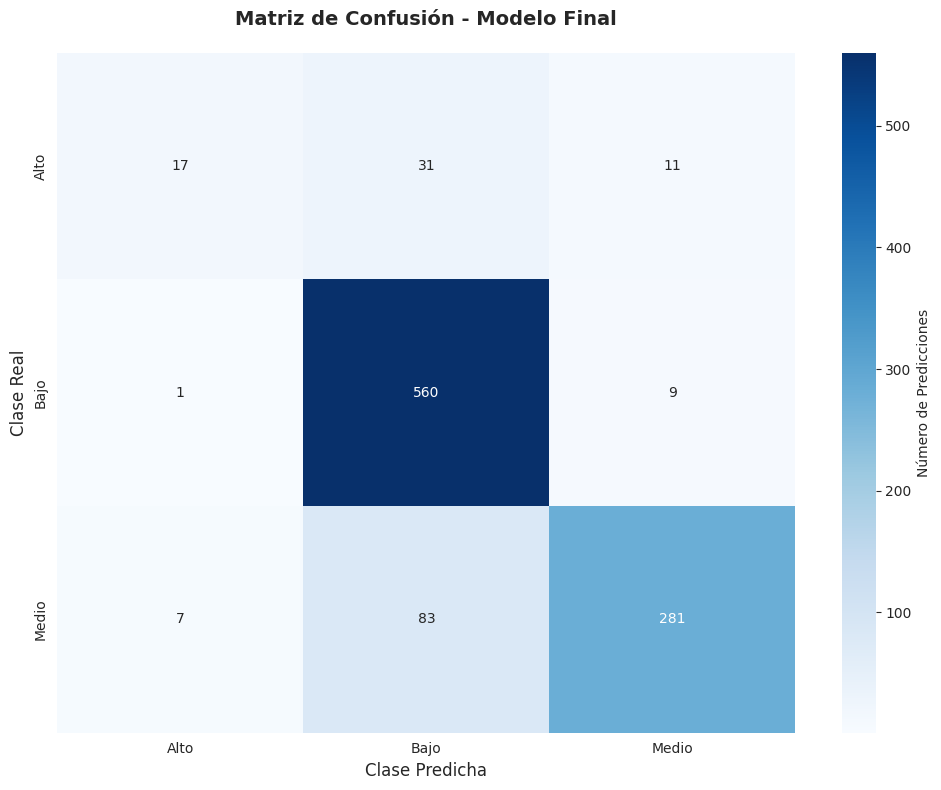


📝 Interpretación:
  • Diagonal principal: Predicciones correctas
  • Fuera de diagonal: Errores de clasificación

✅ Matriz de confusión guardada en /tmp/confusion_matrix.png


In [0]:
# Generar matriz de confusión
print("=" * 70)
print("📊 MATRIZ DE CONFUSIÓN")
print("=" * 70)

# Calcular matriz de confusión
cm = confusion_matrix(y_test_encoded, y_test_pred)

# Crear visualización
fig, ax = plt.subplots(figsize=(10, 8))

# Usar nombres de clases reales
class_names = label_encoder.classes_

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Número de Predicciones'},
    ax=ax
)

ax.set_title('Matriz de Confusión - Modelo Final', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Clase Real', fontsize=12)
ax.set_xlabel('Clase Predicha', fontsize=12)

plt.tight_layout()
plt.savefig('/tmp/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📝 Interpretación:")
print("  • Diagonal principal: Predicciones correctas")
print("  • Fuera de diagonal: Errores de clasificación")
print(f"\n✅ Matriz de confusión guardada en /tmp/confusion_matrix.png")

In [0]:
# Generar reporte de clasificación
print("=" * 70)
print("📊 REPORTE DE CLASIFICACIÓN DETALLADO")
print("=" * 70)

# Reporte de clasificación
report = classification_report(
    y_test_encoded,
    y_test_pred,
    target_names=class_names,
    digits=4
)

print("\n" + report)

# Crear DataFrame para mejor visualización
report_dict = classification_report(
    y_test_encoded,
    y_test_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
report_df = report_df.round(4)

print("\n📊 Métricas por Clase:")
display(report_df)

print("\n📝 Definiciones:")
print("  • Precision: De las predicciones positivas, cuántas fueron correctas")
print("  • Recall: De los casos reales positivos, cuántos fueron detectados")
print("  • F1-Score: Media armónica de Precision y Recall")
print("  • Support: Número de casos reales de cada clase")

📊 REPORTE DE CLASIFICACIÓN DETALLADO

              precision    recall  f1-score   support

        Alto     0.6800    0.2881    0.4048        59
        Bajo     0.8309    0.9825    0.9003       570
       Medio     0.9336    0.7574    0.8363       371

    accuracy                         0.8580      1000
   macro avg     0.8148    0.6760    0.7138      1000
weighted avg     0.8601    0.8580    0.8473      1000


📊 Métricas por Clase:


precision,recall,f1-score,support
0.68,0.2881,0.4048,59.0
0.8309,0.9825,0.9003,570.0
0.9336,0.7574,0.8363,371.0
0.858,0.858,0.858,0.858
0.8148,0.676,0.7138,1000.0
0.8601,0.858,0.8473,1000.0



📝 Definiciones:
  • Precision: De las predicciones positivas, cuántas fueron correctas
  • Recall: De los casos reales positivos, cuántos fueron detectados
  • F1-Score: Media armónica de Precision y Recall
  • Support: Número de casos reales de cada clase


📊 CURVAS ROC (One-vs-Rest)


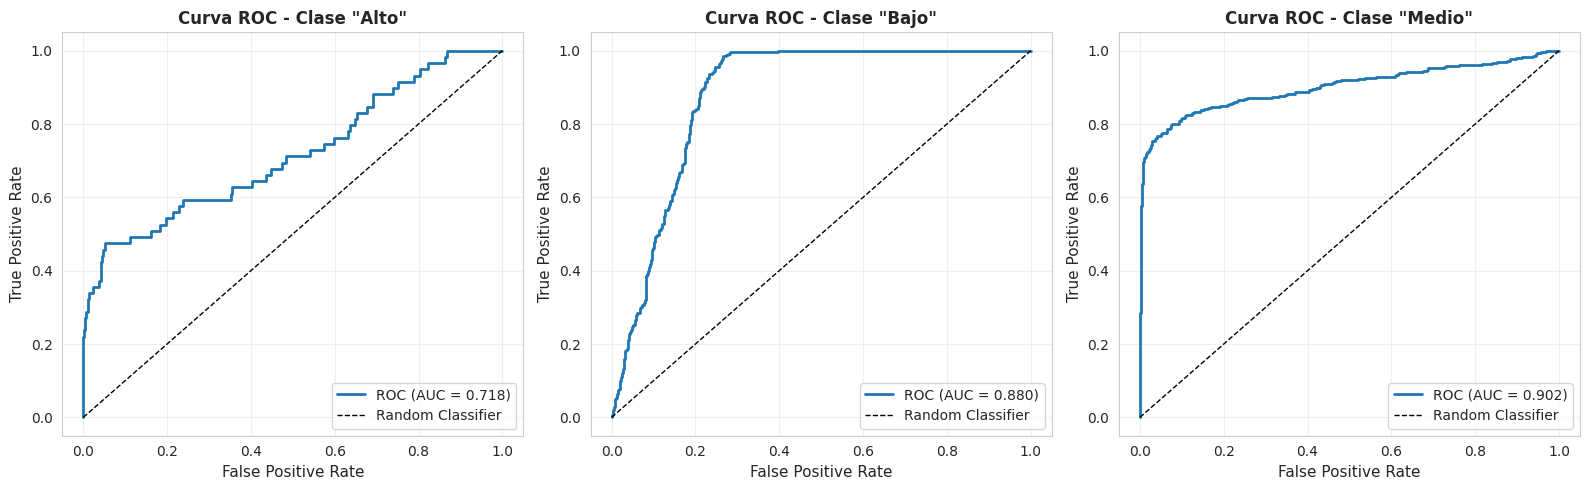


✅ Curvas ROC generadas

📝 Interpretación:
  • AUC = 1.0: Clasificador perfecto
  • AUC = 0.5: Clasificador aleatorio
  • Curva más cercana a la esquina superior izquierda = mejor rendimiento


In [0]:
# Generar curvas ROC para clasificación multiclase
print("=" * 70)
print("📊 CURVAS ROC (One-vs-Rest)")
print("=" * 70)

# Obtener probabilidades de predicción
y_test_proba = final_model.predict_proba(X_test_processed)

# Calcular curvas ROC para cada clase (One-vs-Rest)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, class_name in enumerate(class_names):
    ax = axes[i]
    
    # Binarizar el target para esta clase
    y_test_binary = (y_test_encoded == i).astype(int)
    
    # Calcular curva ROC
    fpr, tpr, _ = roc_curve(y_test_binary, y_test_proba[:, i])
    roc_auc = roc_auc_score(y_test_binary, y_test_proba[:, i])
    
    # Graficar
    ax.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
    
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'Curva ROC - Clase "{class_name}"', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Curvas ROC generadas")
print("\n📝 Interpretación:")
print("  • AUC = 1.0: Clasificador perfecto")
print("  • AUC = 0.5: Clasificador aleatorio")
print("  • Curva más cercana a la esquina superior izquierda = mejor rendimiento")

🎯 IMPORTANCIA DE FEATURES

🔝 Top 20 Features Más Importantes:

   Feature  Importance
 Feature_8    0.201137
 Feature_4    0.199614
 Feature_3    0.118880
 Feature_5    0.092505
 Feature_6    0.054413
 Feature_1    0.023748
 Feature_0    0.023011
Feature_15    0.020365
Feature_18    0.020041
 Feature_7    0.019858
Feature_12    0.019393
 Feature_2    0.018357
Feature_20    0.018223
Feature_21    0.018097
Feature_11    0.017962
Feature_22    0.017592
Feature_10    0.017488
Feature_19    0.017372
Feature_16    0.017117
Feature_13    0.016984


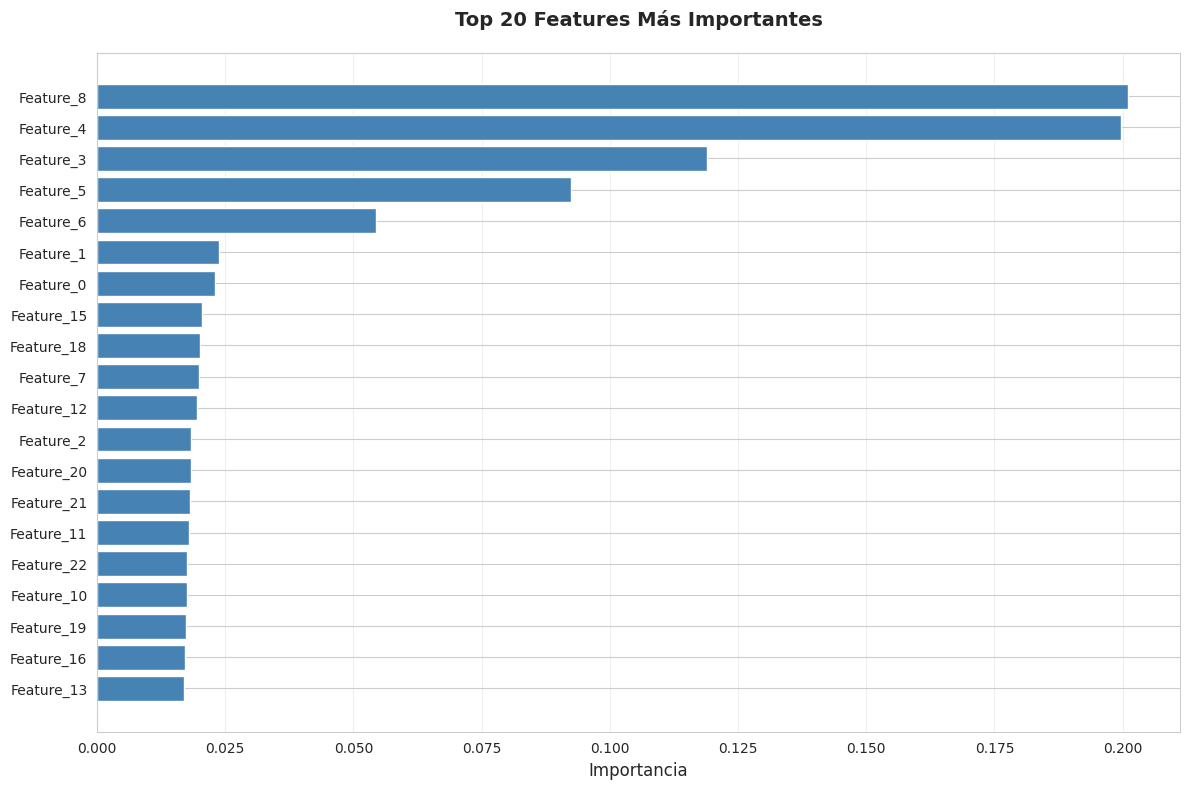


✅ Análisis de importancia completado

📝 Nota: Los nombres de features son genéricos debido al preprocesamiento
   En producción, se mapearían a nombres originales de columnas


In [0]:
# Analizar importancia de features
print("=" * 70)
print("🎯 IMPORTANCIA DE FEATURES")
print("=" * 70)

# Obtener importancia de features del modelo XGBoost
feature_importance = final_model.feature_importances_

# Crear DataFrame con importancias
# Nota: Después del preprocesamiento, tenemos más features debido a one-hot encoding
# Usaremos los índices como nombres por simplicidad
feature_names = [f'Feature_{i}' for i in range(len(feature_importance))]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

# Top 20 features más importantes
top_n = 20
top_features = importance_df.head(top_n)

print(f"\n🔝 Top {top_n} Features Más Importantes:\n")
print(top_features.to_string(index=False))

# Visualizar
fig, ax = plt.subplots(figsize=(12, 8))

top_features_plot = top_features.iloc[::-1]  # Invertir para mejor visualización
ax.barh(range(len(top_features_plot)), top_features_plot['Importance'], color='steelblue')
ax.set_yticks(range(len(top_features_plot)))
ax.set_yticklabels(top_features_plot['Feature'])
ax.set_xlabel('Importancia', fontsize=12)
ax.set_title(f'Top {top_n} Features Más Importantes', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Análisis de importancia completado")
print("\n📝 Nota: Los nombres de features son genéricos debido al preprocesamiento")
print("   En producción, se mapearían a nombres originales de columnas")

In [0]:
# Registrar visualizaciones y métricas en MLflow
print("=" * 70)
print("📦 REGISTRANDO ARTEFACTOS EN MLFLOW")
print("=" * 70)

print("\n🔄 Registrando visualizaciones y métricas...")

# Registrar artefactos en el run del modelo final
with mlflow.start_run(run_id=final_run_id):
    # Registrar imágenes
    mlflow.log_artifact('/tmp/confusion_matrix.png', 'evaluation_plots')
    mlflow.log_artifact('/tmp/roc_curves.png', 'evaluation_plots')
    mlflow.log_artifact('/tmp/feature_importance.png', 'evaluation_plots')
    
    # Registrar reporte de clasificación como JSON

    # Registrar importancia de features como CSV
    importance_df.to_csv('/tmp/feature_importance.csv', index=False)
    mlflow.log_artifact('/tmp/feature_importance.csv', 'evaluation_metrics')
    
    print("\n✅ Artefactos registrados exitosamente en MLflow")
    print("\n📊 Artefactos registrados:")
    print("  • confusion_matrix.png")
    print("  • roc_curves.png")
    print("  • feature_importance.png")
    print("  • feature_importance.csv")
    print(f"\n👁️ Ver artefactos en MLflow Run: {final_run_id}")

print("\n" + "=" * 70)

📦 REGISTRANDO ARTEFACTOS EN MLFLOW

🔄 Registrando visualizaciones y métricas...

✅ Artefactos registrados exitosamente en MLflow

📊 Artefactos registrados:
  • confusion_matrix.png
  • roc_curves.png
  • feature_importance.png
  • confusion_matrix_normalized.png
  • classification_report.json
  • feature_importance.csv

👁️ Ver artefactos en MLflow Run: 3f29aaa2cefc4fdfa77eac41dfb5b4e1

